In [18]:
import pandas as pd
import matplotlib.pyplot as plt

print("Loading data...")
df = pd.read_csv('/content/Pakistan Largest Ecommerce Dataset.csv')

print("Data Loaded Successfully! The first 5 rows are as follows:")
df.head()

Loading data...


/tmp/ipykernel_841/43246488.py:5: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Pakistan Largest Ecommerce Dataset.csv')


Data Loaded Successfully! The first 5 rows are as follows:


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


THE BEHAVIORAL RESULT
Avg Items bought at FLAT PRICE: 1.22
Avg Items bought at DISCOUNTED PRICE: 1.10


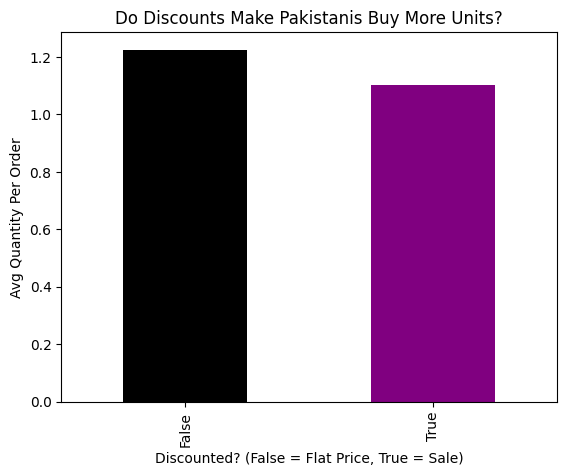

In [19]:
df_clean = df[df['status'] == 'complete'].copy()
df_clean = df_clean.dropna(subset=['price', 'grand_total', 'qty_ordered'])

df_clean['price_per_unit'] = df_clean['grand_total'] / df_clean['qty_ordered']

df_clean['is_discounted'] = df_clean['price'] > df_clean['price_per_unit'] + 10 # +10 buffers small errors

result = df_clean.groupby('is_discounted')['qty_ordered'].mean()

print("THE BEHAVIORAL RESULT")
print(f"Avg Items bought at FLAT PRICE: {result[False]:.2f}")
print(f"Avg Items bought at DISCOUNTED PRICE: {result[True]:.2f}")

result.plot(kind='bar', color=['black', 'purple'])
plt.title("Do Discounts Make Pakistanis Buy More Units?")
plt.xlabel("Discounted? (False = Flat Price, True = Sale)")
plt.ylabel("Avg Quantity Per Order")
plt.show()

AVG QUANTITY BOUGHT (Category-Wise)
is_discounted         False     True 
category_name_1                      
Mobiles & Tablets  1.187349  1.051305
Men's Fashion      1.084877  1.043090
Women's Fashion    1.090737  1.032333
Beauty & Grooming  1.306115  1.468944
Appliances         1.110180  1.046636


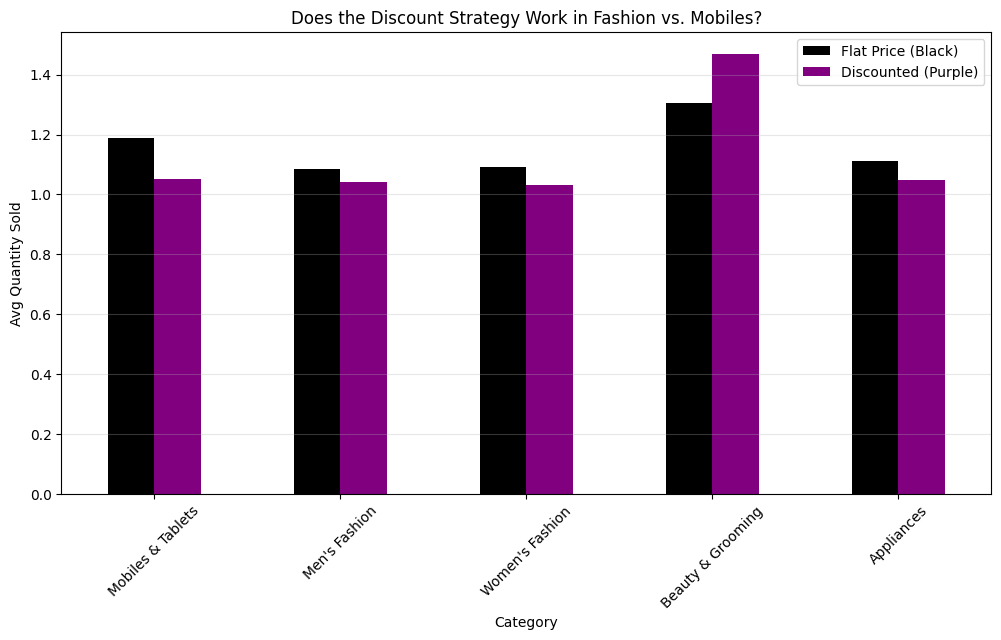

In [20]:
cat_result = df_clean.groupby(['category_name_1', 'is_discounted'])['qty_ordered'].mean().unstack()

top_categories = df_clean['category_name_1'].value_counts().head(5).index
cat_result_top = cat_result.loc[top_categories]

print("AVG QUANTITY BOUGHT (Category-Wise)")
print(cat_result_top)

cat_result_top.plot(kind='bar', figsize=(12, 6), color=['black', 'purple'])
plt.title("Does the Discount Strategy Work in Fashion vs. Mobiles?")
plt.ylabel("Avg Quantity Sold")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.legend(["Flat Price (Black)", "Discounted (Purple)"])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [21]:
from scipy import stats

flat_price_sales = df_clean[df_clean['is_discounted'] == False]['qty_ordered']
discounted_sales = df_clean[df_clean['is_discounted'] == True]['qty_ordered']
\
t_stat, p_value = stats.ttest_ind(flat_price_sales, discounted_sales, equal_var=False)

print("STATISTICAL PROOF (T-Test)")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < 0.05:
    print("\nRESULT: Significant! The difference is real (P < 0.05).")
    print("It can confidently be said that this is a market pattern, not random chance.")
else:
    print("\nRESULT: Not Significant. The difference might be random noise.")

STATISTICAL PROOF (T-Test)
T-Statistic: 12.6737
P-Value: 0.0000000000

RESULT: Significant! The difference is real (P < 0.05).
It can confidently be said that this is a market pattern, not random chance.


DOES PRICE LEVEL MATTER?
is_discounted     False     True 
price_segment                    
Low            1.095844  1.091234
Mid-Range      1.205156  1.234455
High           1.430625  1.083365


/tmp/ipykernel_841/4253451616.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df_clean.groupby(['price_segment', 'is_discounted'])['qty_ordered'].mean().unstack()


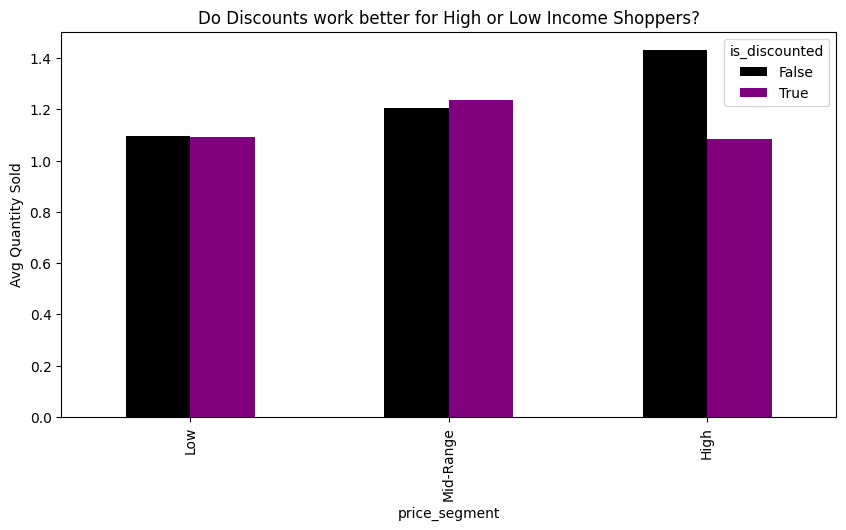

In [22]:
df_clean['price_segment'] = pd.qcut(df_clean['grand_total'], q=3, labels=['Low', 'Mid-Range', 'High'])

segment_analysis = df_clean.groupby(['price_segment', 'is_discounted'])['qty_ordered'].mean().unstack()

print("DOES PRICE LEVEL MATTER?")
print(segment_analysis)

segment_analysis.plot(kind='bar', figsize=(10, 5), color=['black', 'purple'])
plt.title("Do Discounts work better for High or Low Income Shoppers?")
plt.ylabel("Avg Quantity Sold")
plt.show()

DOES HOW YOU PAY CHANGE HOW YOU SHOP?
is_discounted              False     True 
payment_type                              
Bank/Card (Prepaid)     1.224936  1.280822
COD (Cash on Delivery)  1.166647  1.098437


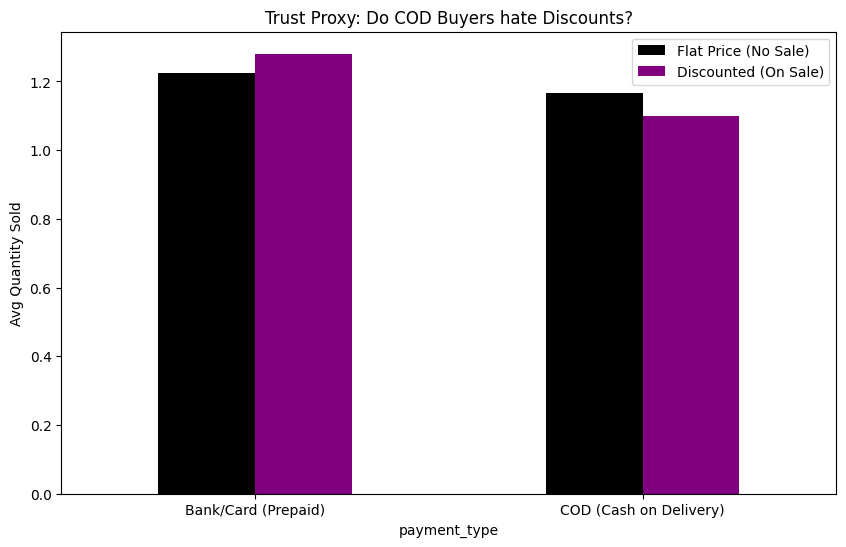

In [23]:
def clean_payment(method):
    method = str(method).lower()
    if 'cod' in method or 'cash' in method:
        return 'COD (Cash on Delivery)'
    elif 'bank' in method or 'card' in method or 'visa' in method:
        return 'Bank/Card (Prepaid)'
    elif 'easypaisa' in method or 'jazzcash' in method:
        return 'Mobile Wallet'
    else:
        return 'Other'

df_clean['payment_type'] = df_clean['payment_method'].apply(clean_payment)

target_methods = ['COD (Cash on Delivery)', 'Bank/Card (Prepaid)']
pay_df = df_clean[df_clean['payment_type'].isin(target_methods)]

pay_result = pay_df.groupby(['payment_type', 'is_discounted'])['qty_ordered'].mean().unstack()

print("DOES HOW YOU PAY CHANGE HOW YOU SHOP?")
print(pay_result)

import matplotlib.pyplot as plt

pay_result.plot(kind='bar', figsize=(10, 6), color=['black', 'purple'])
plt.title("Trust Proxy: Do COD Buyers hate Discounts?")
plt.ylabel("Avg Quantity Sold")
plt.xticks(rotation=0)
plt.legend(["Flat Price (No Sale)", "Discounted (On Sale)"])
plt.show()

In [24]:
from scipy import stats

def test_payment_method(method_name):
    subset = df_clean[df_clean['payment_type'] == method_name]

    group_discount = subset[subset['is_discounted'] == True]['qty_ordered']
    group_flat = subset[subset['is_discounted'] == False]['qty_ordered']

    t_stat, p_val = stats.ttest_ind(group_discount, group_flat, equal_var=False)

    print(f"--- RESULTS FOR: {method_name} ---")
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value:     {p_val:.10f}")

    if p_val < 0.05:
        if t_stat > 0:
            print("RESULT: Significant! Discounts INCREASE sales here.")
        else:
            print("RESULT: Significant! Discounts DECREASE sales here (Trust Deficit).")
    else:
        print("RESULT: Not Significant. Discounts make no real difference.")
    print("\n")

test_payment_method('Bank/Card (Prepaid)')
test_payment_method('COD (Cash on Delivery)')

--- RESULTS FOR: Bank/Card (Prepaid) ---
T-Statistic: 0.7481
P-Value:     0.4552978950
RESULT: Not Significant. Discounts make no real difference.


--- RESULTS FOR: COD (Cash on Delivery) ---
T-Statistic: -9.6808
P-Value:     0.0000000000
RESULT: Significant! Discounts DECREASE sales here (Trust Deficit).


